In [1]:
# importa bibliotecas necessárias
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

In [2]:
# carrega dataset de qualidade de vinhos
wine_df = pd.read_csv("winequality-red.csv")

print("WINE QUALITY DATASET")
print(f"   Shape    : {wine_df.shape[0]:,} rows x {wine_df.shape[1]} columns")
print(f"   Missing  : {wine_df.isnull().sum().sum()}")
print(f"   NaN      : {wine_df.isna().sum().sum()}")

print("\nWINE QUALITY COLUMNS")
print(f"   Columns  : {wine_df.columns}")

WINE QUALITY DATASET
   Shape    : 1,599 rows x 12 columns
   Missing  : 0
   NaN      : 0

WINE QUALITY COLUMNS
   Columns  : Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


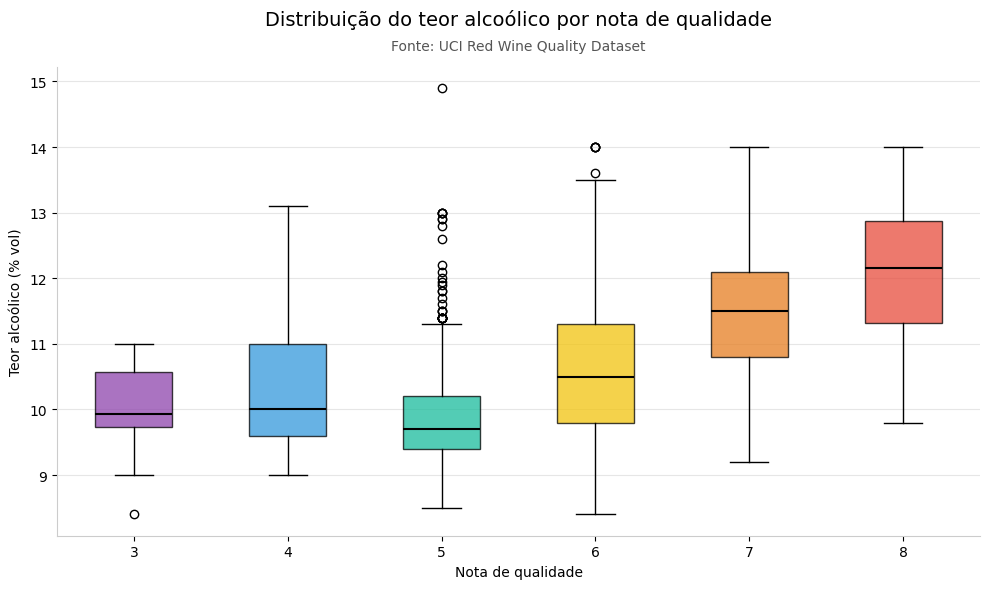

In [4]:
# agrupa o teor alcoólico por nível de qualidade
qualities = sorted(wine_df["quality"].unique())
data = [wine_df.loc[wine_df["quality"] == q, "alcohol"].values for q in qualities]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data,
    tick_labels=qualities,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
)

colors = ["#8E44AD", "#3498DB", "#1ABC9C", "#F1C40F", "#E67E22", "#E74C3C"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title(
    "Distribuição do teor alcoólico por nota de qualidade", fontsize=14, pad=30
)
ax.text(
    0.5,
    1.03,
    "Fonte: UCI Red Wine Quality Dataset",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Teor alcoólico (% vol)")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#cccccc")

ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("Boxplot alcool por qualidade.png", dpi=300)
plt.show()

In [5]:
# carrega dataset de faixas musicais do Spotify
spotify_df = pd.read_csv("spotify_tracks.csv")

print("SPOTIFY TRACKS DATASET")
print(f"   Shape    : {spotify_df.shape[0]:,} rows x {spotify_df.shape[1]} columns")
print(f"   Missing  : {spotify_df.isnull().sum().sum()}")
print(f"   NaN      : {spotify_df.isna().sum().sum()}")

print("\nSPOTIFY COLUMNS")
print(f"   Columns  : {spotify_df.columns}")

SPOTIFY TRACKS DATASET
   Shape    : 114,000 rows x 21 columns
   Missing  : 3
   NaN      : 3

SPOTIFY COLUMNS
   Columns  : Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


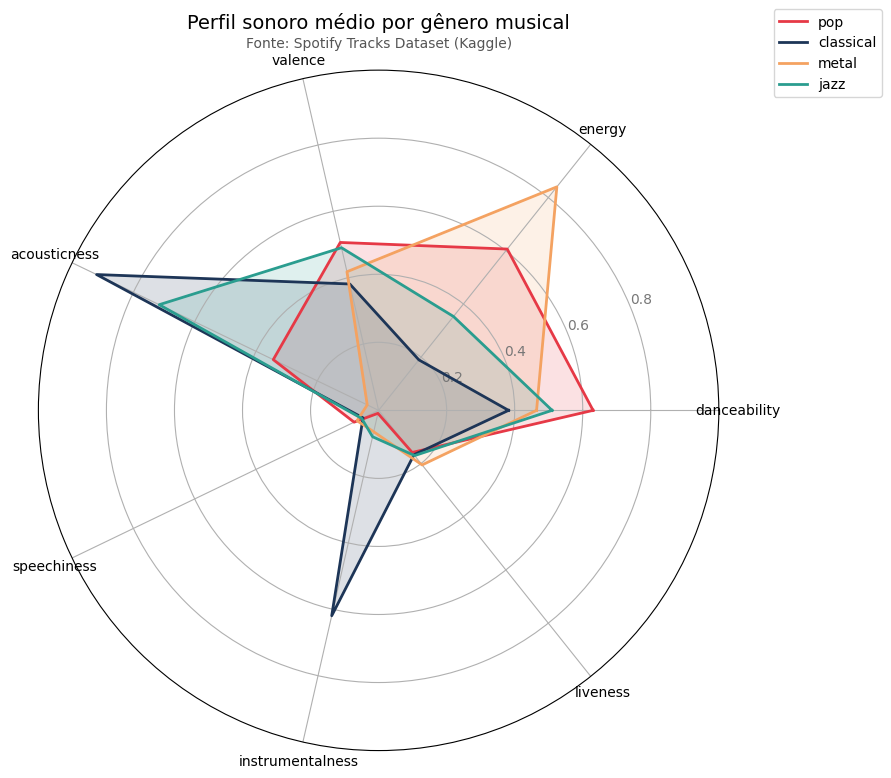

In [7]:
# define atributos e gêneros analisados
features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
]
genres = ["pop", "classical", "metal", "jazz"]

# calcula a média de cada atributo por gênero
profile = (
    spotify_df[spotify_df["track_genre"].isin(genres)]
    .groupby("track_genre")[features]
    .mean()
    .reindex(genres)
)

# define os ângulos do radar
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = ["#E63946", "#1D3557", "#F4A261", "#2A9D8F"]

for genre, color in zip(genres, colors):
    values = profile.loc[genre].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=genre)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], color="#777777")
ax.set_ylim(0, 1)

ax.set_title("Perfil sonoro médio por gênero musical", fontsize=14, pad=30)
ax.text(
    0.5,
    1.03,
    "Fonte: Spotify Tracks Dataset (Kaggle)",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
plt.tight_layout()
plt.savefig("Radar generos Spotify.png", dpi=300)
plt.show()

In [8]:
# carrega dataset do Titanic
titanic_df = pd.read_csv("Titanic-Dataset.csv")

print("TITANIC DATASET")
print(f"   Shape    : {titanic_df.shape[0]:,} rows x {titanic_df.shape[1]} columns")
print(f"   Missing  : {titanic_df.isnull().sum().sum()}")
print(f"   NaN      : {titanic_df.isna().sum().sum()}")

print("\nTITANIC COLUMNS")
print(f"   Columns  : {titanic_df.columns}")

TITANIC DATASET
   Shape    : 891 rows x 12 columns
   Missing  : 866
   NaN      : 866

TITANIC COLUMNS
   Columns  : Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [9]:
# tabela cruzada (Pclass x Sex x Survived)
cross = pd.crosstab(
    index=[titanic_df["Pclass"], titanic_df["Sex"]],
    columns=titanic_df["Survived"],
).rename(columns={0: "Não sobreviveu", 1: "Sobreviveu"})

print(cross)

Survived       Não sobreviveu  Sobreviveu
Pclass Sex                               
1      female               3          91
       male                77          45
2      female               6          70
       male                91          17
3      female              72          72
       male               300          47


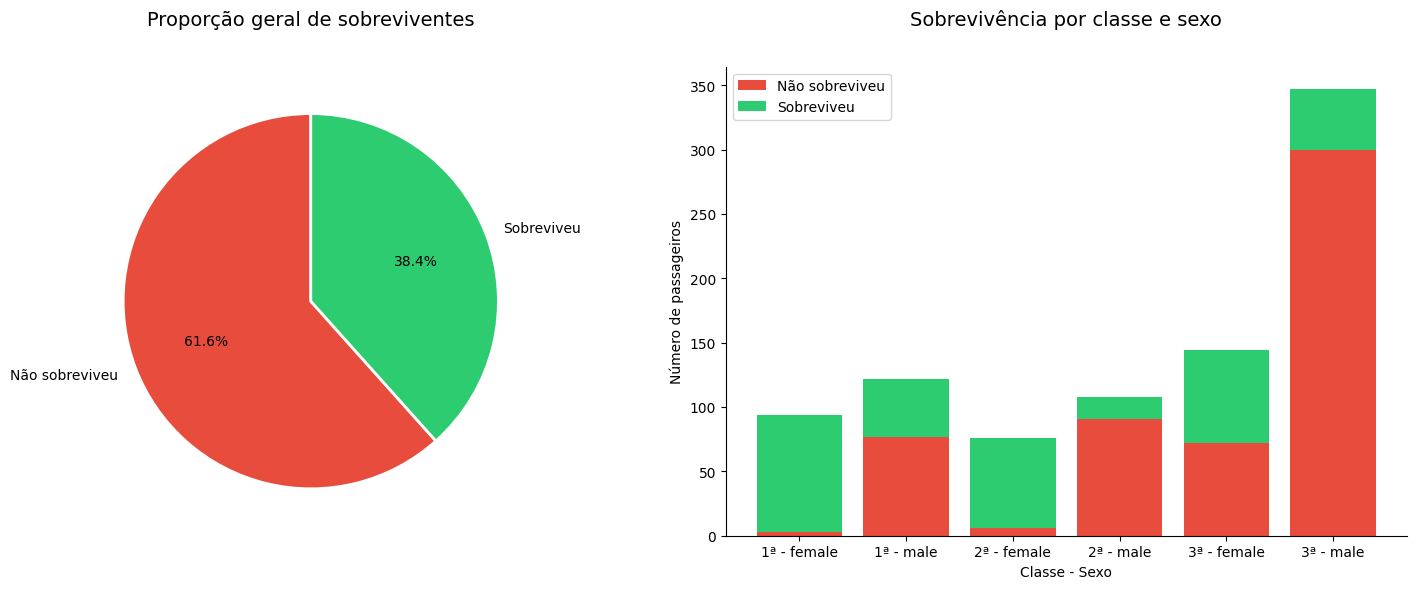

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1: pizza com proporção geral ---
surv_counts = titanic_df["Survived"].value_counts().sort_index()
labels = ["Não sobreviveu", "Sobreviveu"]
colors_pie = ["#E74C3C", "#2ECC71"]

axes[0].pie(
    surv_counts,
    labels=labels,
    colors=colors_pie,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
axes[0].set_title("Proporção geral de sobreviventes", fontsize=14, pad=30)

# --- Subplot 2: barras empilhadas por classe x sexo ---
groups = cross.index.map(lambda x: f"{x[0]}ª - {x[1]}")
nao = cross["Não sobreviveu"].values
sim = cross["Sobreviveu"].values

axes[1].bar(groups, nao, color="#E74C3C", label="Não sobreviveu")
axes[1].bar(groups, sim, bottom=nao, color="#2ECC71", label="Sobreviveu")

axes[1].set_title("Sobrevivência por classe e sexo", fontsize=14, pad=30)
axes[1].set_xlabel("Classe - Sexo")
axes[1].set_ylabel("Número de passageiros")
axes[1].legend()

for spine in ["top", "right"]:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("Titanic pizza + barras.png", dpi=300)
plt.show()